# 08 - Validacao Final dos Melhores Modelos

Este notebook responde a pergunta final do projeto: os melhores modelos da segmentacao bruta, combinados com suas melhores binarizacoes, ja sao suficientes para segmentar bufalos sem retreinamento? A validacao usa apenas o cenario configurado em `analysis.validacao_final` e aplica thresholds absolutos para decidir se os finalistas passam ou nao no criterio minimo de qualidade.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
plt.rcParams['figure.max_open_warning'] = 0
import pandas as pd
from IPython.display import Markdown, display

root_dir = Path.cwd()
if not (root_dir / 'src').exists() and (root_dir.parent / 'src').exists():
    root_dir = root_dir.parent

if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

from src.analysis import (
    BINARIZED_METRIC_CONFIGS,
    MetricsCollector,
    RAW_METRIC_CONFIGS,
    build_analysis_scenarios,
    build_binarized_metrics_dataframe,
    build_descriptive_stats,
    build_finalist_base,
    build_model_comparison_tests,
    build_scenario_rankings,
    build_strategy_rankings_within_model_by_scenario,
    build_threshold_decision_table,
    select_best_strategies_for_models,
    select_top_models_for_final_validation,
)
from src.config import (
    SEGMENTACAO_BINARIZADA_ANALISE_EXECUCAO,
    SEGMENTACAO_BINARIZADA_CENARIO_IDEAL_TAGS_PERMITIDAS,
    SEGMENTACAO_BRUTA_ANALISE_EXECUCAO,
    SEGMENTACAO_BRUTA_CENARIO_IDEAL_TAGS_PERMITIDAS,
    VALIDACAO_FINAL_ACCEPTANCE_RULE,
    VALIDACAO_FINAL_AREA_SIMILARITY_MIN,
    VALIDACAO_FINAL_CENARIO_BASE,
    VALIDACAO_FINAL_IOU_MIN,
    VALIDACAO_FINAL_PERIMETRO_SIMILARITY_MIN,
    VALIDACAO_FINAL_PRECISION_MIN,
    VALIDACAO_FINAL_RECALL_MIN,
    VALIDACAO_FINAL_TOP_N_MODELOS,
)
from src.io.path_resolver import PathResolver
from src.repositories import ImagemRepository
from src.visualization import (
    build_artifact_output_dir,
    build_artifact_stem,
    export_figure_with_csv,
    export_table_csv,
    plot_finalist_metric_heatmap,
    plot_pairwise_pvalue_heatmap,
    plot_threshold_pass_heatmap,
)

/home/victor/Desktop/projeto-bufalos/worktrees/analise-estatistica-segmentacao-bruta/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Carregamento das bases e parametros da validacao

O notebook usa a mesma execucao fixa da analise bruta e da analise binarizada. A selecao dos finalistas parte do ranking bruto no cenario configurado e, em seguida, escolhe a melhor estrategia de binarizacao de cada modelo nesse mesmo cenario.

In [2]:
def _wide_means_from_stats(df_stats):
    metric_names = sorted(df_stats['metric_name'].unique().tolist())
    base_columns = ['combo', 'modelo', 'estrategia_binarizacao']
    result = df_stats[base_columns].drop_duplicates().reset_index(drop=True)
    for metric_name in metric_names:
        df_metric = df_stats.loc[df_stats['metric_name'] == metric_name, base_columns + ['count', 'mean', 'median', 'std', 'min', 'max']].copy()
        df_metric = df_metric.rename(columns={
            'count': f'{metric_name}_count',
            'mean': metric_name,
            'median': f'{metric_name}_median',
            'std': f'{metric_name}_std',
            'min': f'{metric_name}_min_observado',
            'max': f'{metric_name}_max_observado',
        })
        result = result.merge(df_metric, on=base_columns, how='left')
    return result

metric_names = ['iou', 'precision', 'recall', 'area_similarity', 'perimetro_similarity']
metric_thresholds = {
    'iou': VALIDACAO_FINAL_IOU_MIN,
    'precision': VALIDACAO_FINAL_PRECISION_MIN,
    'recall': VALIDACAO_FINAL_RECALL_MIN,
    'area_similarity': VALIDACAO_FINAL_AREA_SIMILARITY_MIN,
    'perimetro_similarity': VALIDACAO_FINAL_PERIMETRO_SIMILARITY_MIN,
}

path_resolver = PathResolver.from_config()
artifact_output_dir = build_artifact_output_dir(
    path_resolver.generated_dir,
    'notebook_08_validacao_final_melhores_modelos',
)

collector = MetricsCollector(force_recalculate=False)
df_base_bruta = collector.collect_all_metrics()
df_base_bruta_execucao = df_base_bruta.loc[df_base_bruta['execucao'] == SEGMENTACAO_BRUTA_ANALISE_EXECUCAO].copy()
if df_base_bruta_execucao.empty:
    raise ValueError(f'Nenhum registro bruto encontrado para a execucao {SEGMENTACAO_BRUTA_ANALISE_EXECUCAO}.')

df_base_binarizada = build_binarized_metrics_dataframe(
    ImagemRepository().list(),
    execucao_escolhida=SEGMENTACAO_BINARIZADA_ANALISE_EXECUCAO,
)

print(f'Cenario base da validacao final: {VALIDACAO_FINAL_CENARIO_BASE}')
print(f'Top N modelos: {VALIDACAO_FINAL_TOP_N_MODELOS}')
print(f'Regra de aceitacao: {VALIDACAO_FINAL_ACCEPTANCE_RULE}')
print(f'Execucao bruta utilizada: {SEGMENTACAO_BRUTA_ANALISE_EXECUCAO}')
print(f'Execucao binarizada utilizada: {SEGMENTACAO_BINARIZADA_ANALISE_EXECUCAO}')
print(f'Thresholds: {metric_thresholds}')
print(f'Diretorio de artefatos: {artifact_output_dir}')

✓ Métricas carregadas do SQLite
Cenario base da validacao final: apenas_ok
Top N modelos: 3
Regra de aceitacao: all_metrics
Execucao bruta utilizada: 1
Execucao binarizada utilizada: 1
Thresholds: {'iou': 0.97, 'precision': 0.99, 'recall': 0.985, 'area_similarity': 0.99, 'perimetro_similarity': 0.96}
Diretorio de artefatos: /home/victor/Desktop/projeto-bufalos/worktrees/analise-estatistica-segmentacao-bruta/generated/notebook_08_validacao_final_melhores_modelos


## Selecao dos finalistas

Primeiro selecionamos os melhores modelos da segmentacao bruta no cenario configurado. Em seguida, para cada um deles, escolhemos a melhor estrategia de binarizacao no mesmo cenario. O resultado e um conjunto reduzido de combinacoes finalistas.

In [3]:
df_ranking_modelos = build_scenario_rankings(
    df_base=df_base_bruta_execucao,
    metric_configs=RAW_METRIC_CONFIGS,
    group_by=['modelo'],
    ideal_allowed_tags=SEGMENTACAO_BRUTA_CENARIO_IDEAL_TAGS_PERMITIDAS,
    primary_metric='auprc',
)

df_top_modelos = select_top_models_for_final_validation(
    df_ranking_modelos,
    scenario_key=VALIDACAO_FINAL_CENARIO_BASE,
    top_n=VALIDACAO_FINAL_TOP_N_MODELOS,
)
display(df_top_modelos)
export_table_csv(
    artifact_output_dir,
    build_artifact_stem('notebook_08_validacao_final_melhores_modelos', 'tabela', 'top_modelos_brutos'),
    df_top_modelos,
)

df_ranking_estrategia_por_modelo = build_strategy_rankings_within_model_by_scenario(
    df_base=df_base_binarizada,
    metric_configs=BINARIZED_METRIC_CONFIGS,
    ideal_allowed_tags=SEGMENTACAO_BINARIZADA_CENARIO_IDEAL_TAGS_PERMITIDAS,
    primary_metric='iou',
)

selected_models = df_top_modelos['modelo'].tolist()
df_melhor_estrategia = select_best_strategies_for_models(
    df_ranking_estrategia_por_modelo,
    selected_models,
    scenario_key=VALIDACAO_FINAL_CENARIO_BASE,
)
display(df_melhor_estrategia)
export_table_csv(
    artifact_output_dir,
    build_artifact_stem('notebook_08_validacao_final_melhores_modelos', 'tabela', 'melhor_binarizacao_por_modelo'),
    df_melhor_estrategia,
)

,modelo,auprc,soft_dice,brier_score,rank_auprc,rank_soft_dice,rank_brier_score,mean_rank,wins,scenario_key,scenario_label,count_registros,count_imagens,scenario_rank
0,birefnet-hrsod,0.998457,0.983055,0.003135,1.0,4.0,1.0,2.0,2,apenas_ok,Apenas imagens ok,3458,247,1
1,birefnet-general,0.995628,0.986314,0.003149,3.0,1.0,2.0,2.0,1,apenas_ok,Apenas imagens ok,3458,247,2
2,birefnet-massive,0.996384,0.983877,0.003636,2.0,3.0,4.0,3.0,0,apenas_ok,Apenas imagens ok,3458,247,3


,estrategia_binarizacao,iou,precision,recall,area_similarity,perimetro_similarity,rank_iou,rank_precision,rank_recall,rank_area_similarity,...,mean_rank,wins,strategy_rank_within_model,scenario_key,scenario_label,modelo,count_registros,count_imagens,count_registros_modelo,count_imagens_modelo
0,LimiarFixoBaixa,0.980829,0.992427,0.988235,0.993298,0.965270,1.0,7.0,2.0,2.0,...,2.8,1,1,apenas_ok,Apenas imagens ok,birefnet-general,1976,247,1976,247
1,LimiarFixoBaixa,0.979075,0.990173,0.988685,0.994001,0.963704,1.0,7.0,2.0,1.0,...,2.4,3,1,apenas_ok,Apenas imagens ok,birefnet-hrsod,1976,247,1976,247
2,LimiarFixoBaixa,0.977874,0.991569,0.986057,0.990479,0.970967,2.0,7.0,2.0,2.0,...,3.2,0,1,apenas_ok,Apenas imagens ok,birefnet-massive,1976,247,1976,247


PosixPath('/home/victor/Desktop/projeto-bufalos/worktrees/analise-estatistica-segmentacao-bruta/generated/notebook_08_validacao_final_melhores_modelos/notebook_08_validacao_final_melhores_modelos_tabela_melhor_binarizacao_por_modelo.csv')

## Base reduzida dos finalistas

Aqui cruzamos os modelos e estrategias selecionados com a base linha a linha do cenario base. Depois, resumimos as metricas medias das combinacoes finalistas para preparar a avaliacao por thresholds.

In [4]:
scenario_map = {scenario.scenario_key: scenario for scenario in build_analysis_scenarios(
    df_base=df_base_binarizada,
    ideal_allowed_tags=SEGMENTACAO_BINARIZADA_CENARIO_IDEAL_TAGS_PERMITIDAS,
)}
scenario_slice = scenario_map[VALIDACAO_FINAL_CENARIO_BASE]
df_finalistas = df_melhor_estrategia[['modelo', 'estrategia_binarizacao']].copy()
df_finalistas_base = build_finalist_base(scenario_slice.df, df_finalistas)
df_finalistas_base['combo'] = df_finalistas_base['modelo'] + ' | ' + df_finalistas_base['estrategia_binarizacao']

df_resumo_finalistas_long = build_descriptive_stats(
    df_base=df_finalistas_base,
    metric_configs=BINARIZED_METRIC_CONFIGS,
    group_by=['combo', 'modelo', 'estrategia_binarizacao'],
)
df_resumo_finalistas = _wide_means_from_stats(df_resumo_finalistas_long)
display(df_resumo_finalistas)
export_table_csv(
    artifact_output_dir,
    build_artifact_stem('notebook_08_validacao_final_melhores_modelos', 'tabela', 'resumo_finalistas'),
    df_resumo_finalistas,
)

,combo,modelo,estrategia_binarizacao,area_similarity_count,area_similarity,area_similarity_median,area_similarity_std,area_similarity_min_observado,area_similarity_max_observado,iou_count,...,precision_median,precision_std,precision_min_observado,precision_max_observado,recall_count,recall,recall_median,recall_std,recall_min_observado,recall_max_observado
0,birefnet-general | LimiarFixoBaixa,birefnet-general,LimiarFixoBaixa,247,0.993298,0.995766,0.006688,0.963253,0.999951,247,...,0.993415,0.004321,0.962039,0.998702,247,0.988235,0.989591,0.006552,0.944696,0.997243
1,birefnet-hrsod | LimiarFixoBaixa,birefnet-hrsod,LimiarFixoBaixa,247,0.994001,0.995197,0.005311,0.967631,0.999995,247,...,0.991633,0.005571,0.956993,0.998413,247,0.988685,0.989446,0.005273,0.955479,0.997154
2,birefnet-massive | LimiarFixoBaixa,birefnet-massive,LimiarFixoBaixa,247,0.990479,0.992817,0.009213,0.936035,0.999970,247,...,0.994011,0.010559,0.892181,0.999014,247,0.986057,0.987683,0.006653,0.949249,0.995838


PosixPath('/home/victor/Desktop/projeto-bufalos/worktrees/analise-estatistica-segmentacao-bruta/generated/notebook_08_validacao_final_melhores_modelos/notebook_08_validacao_final_melhores_modelos_tabela_resumo_finalistas.csv')

## Validacao por thresholds

A regra de aceitacao deste notebook e propositalmente rigida: cada combinacao finalista so e considerada suficiente se ultrapassar os thresholds minimos em todas as metricas binarizadas. Se nem os finalistas atenderem a esse criterio, a interpretacao passa a apontar necessidade de retreinamento.

,combo,modelo,estrategia_binarizacao,iou,precision,recall,area_similarity,perimetro_similarity,iou_min,iou_ok,precision_min,precision_ok,recall_min,recall_ok,area_similarity_min,area_similarity_ok,perimetro_similarity_min,perimetro_similarity_ok,metricas_reprovadas,aprovado
0,birefnet-general | LimiarFixoBaixa,birefnet-general,LimiarFixoBaixa,0.980829,0.992427,0.988235,0.993298,0.965270,0.97,True,0.99,True,0.985,True,0.99,True,0.96,True,,True
1,birefnet-hrsod | LimiarFixoBaixa,birefnet-hrsod,LimiarFixoBaixa,0.979075,0.990173,0.988685,0.994001,0.963704,0.97,True,0.99,True,0.985,True,0.99,True,0.96,True,,True
2,birefnet-massive | LimiarFixoBaixa,birefnet-massive,LimiarFixoBaixa,0.977874,0.991569,0.986057,0.990479,0.970967,0.97,True,0.99,True,0.985,True,0.99,True,0.96,True,,True


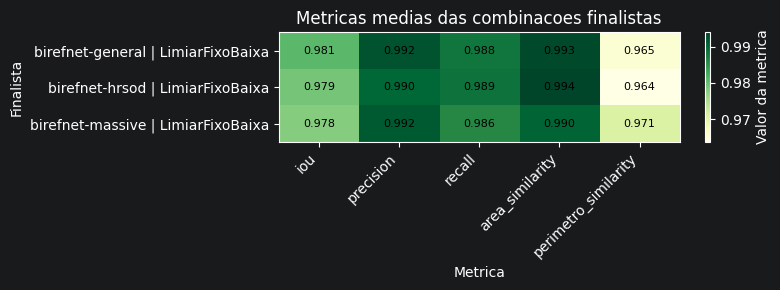

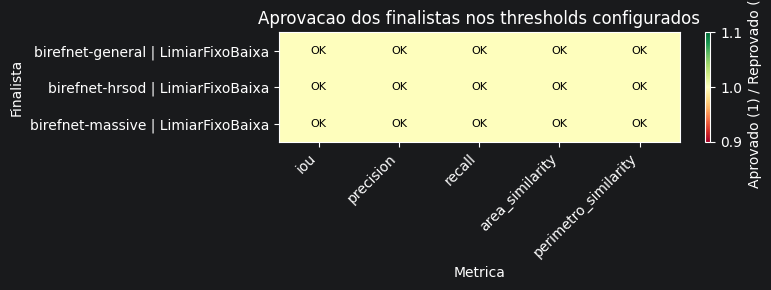

In [5]:
df_decisao_thresholds = build_threshold_decision_table(
    df_resumo_finalistas[['combo', 'modelo', 'estrategia_binarizacao', *metric_names]].copy(),
    metric_thresholds,
    BINARIZED_METRIC_CONFIGS,
    acceptance_rule=VALIDACAO_FINAL_ACCEPTANCE_RULE,
)
display(df_decisao_thresholds)
export_table_csv(
    artifact_output_dir,
    build_artifact_stem('notebook_08_validacao_final_melhores_modelos', 'tabela', 'decisao_thresholds'),
    df_decisao_thresholds,
)

fig, _ = plot_finalist_metric_heatmap(
    df_resumo_finalistas[['combo', *metric_names]].copy(),
    metric_names,
    title='Metricas medias das combinacoes finalistas',
)
export_figure_with_csv(
    artifact_output_dir,
    build_artifact_stem('notebook_08_validacao_final_melhores_modelos', 'heatmap', 'metricas_finalistas'),
    fig,
    df_resumo_finalistas[['combo', *metric_names]].copy(),
)
plt.show()
plt.close(fig)

fig, _ = plot_threshold_pass_heatmap(
    df_decisao_thresholds[['combo', *(f'{metric_name}_ok' for metric_name in metric_names)]].copy(),
    metric_names,
    title='Aprovacao dos finalistas nos thresholds configurados',
)
export_figure_with_csv(
    artifact_output_dir,
    build_artifact_stem('notebook_08_validacao_final_melhores_modelos', 'heatmap', 'aprovacao_thresholds'),
    fig,
    df_decisao_thresholds,
)
plt.show()
plt.close(fig)

## Testes estatisticos entre os finalistas

Os thresholds respondem se os finalistas passam ou nao no criterio minimo absoluto. Os testes abaixo complementam essa leitura mostrando se, entre as combinacoes finalistas, ha diferencas estatisticas nas metricas binarizadas.

,metric_name,comparison_scope,test_name,group_a,group_b,n_group_a,n_group_b,statistic,p_value,p_value_adjusted,effect_size,effect_size_label,mean_group_a,mean_group_b,median_group_a,median_group_b,favored_group
0,iou,global,kruskal_wallis,all_models,,741,3,13.700454,1.059215e-03,1.059215e-03,NaN,NaN,0.979260,0.979260,0.980946,0.980946,NaN
1,iou,pairwise,dunn_holm,birefnet-general | LimiarFixoBaixa,birefnet-hrsod | LimiarFixoBaixa,247,247,3.335957,8.500645e-04,2.550194e-03,0.176318,small,0.980829,0.979075,0.982172,0.980363,birefnet-general | LimiarFixoBaixa
2,iou,pairwise,dunn_holm,birefnet-general | LimiarFixoBaixa,birefnet-massive | LimiarFixoBaixa,247,247,3.056822,2.236974e-03,4.473947e-03,0.156026,small,0.980829,0.977874,0.982172,0.980372,birefnet-general | LimiarFixoBaixa
3,iou,pairwise,dunn_holm,birefnet-hrsod | LimiarFixoBaixa,birefnet-massive | LimiarFixoBaixa,247,247,-0.279135,7.801413e-01,7.801413e-01,-0.011621,negligible,0.979075,0.977874,0.980363,0.980372,birefnet-hrsod | LimiarFixoBaixa
4,precision,global,kruskal_wallis,all_models,,741,3,50.384634,1.145818e-11,1.145818e-11,NaN,NaN,0.991390,0.991390,0.993129,0.993129,NaN
5,precision,pairwise,dunn_holm,birefnet-general | LimiarFixoBaixa,birefnet-hrsod | LimiarFixoBaixa,247,247,4.921434,8.591217e-07,1.718243e-06,0.270927,small,0.992427,0.990173,0.993415,0.991633,birefnet-general | LimiarFixoBaixa
6,precision,pairwise,dunn_holm,birefnet-general | LimiarFixoBaixa,birefnet-massive | LimiarFixoBaixa,247,247,-1.969078,4.894411e-02,4.894411e-02,-0.117442,negligible,0.992427,0.991569,0.993415,0.994011,birefnet-general | LimiarFixoBaixa
7,precision,pairwise,dunn_holm,birefnet-hrsod | LimiarFixoBaixa,birefnet-massive | LimiarFixoBaixa,247,247,-6.890513,5.559109e-12,1.667733e-11,-0.343146,medium,0.990173,0.991569,0.991633,0.994011,birefnet-massive | LimiarFixoBaixa
8,recall,global,kruskal_wallis,all_models,,741,3,28.602338,6.152918e-07,6.152918e-07,NaN,NaN,0.987659,0.987659,0.989047,0.989047,NaN
9,recall,pairwise,dunn_holm,birefnet-general | LimiarFixoBaixa,birefnet-hrsod | LimiarFixoBaixa,247,247,-0.017236,9.862485e-01,9.862485e-01,0.005622,negligible,0.988235,0.988685,0.989591,0.989446,birefnet-hrsod | LimiarFixoBaixa


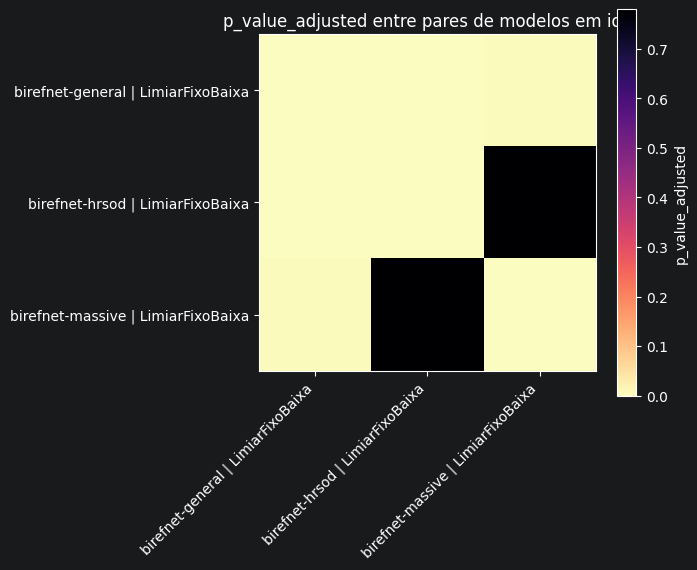

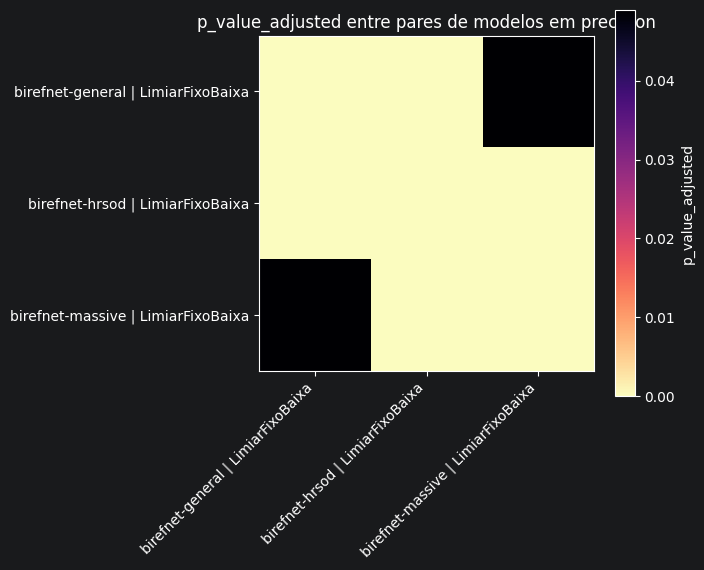

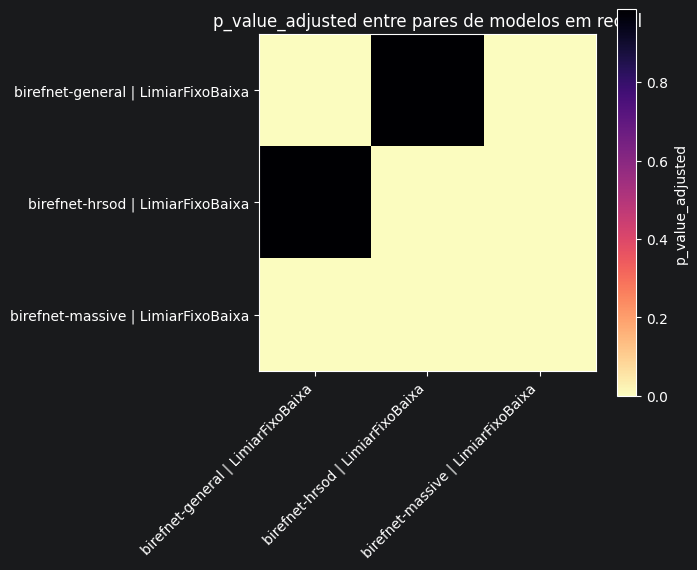

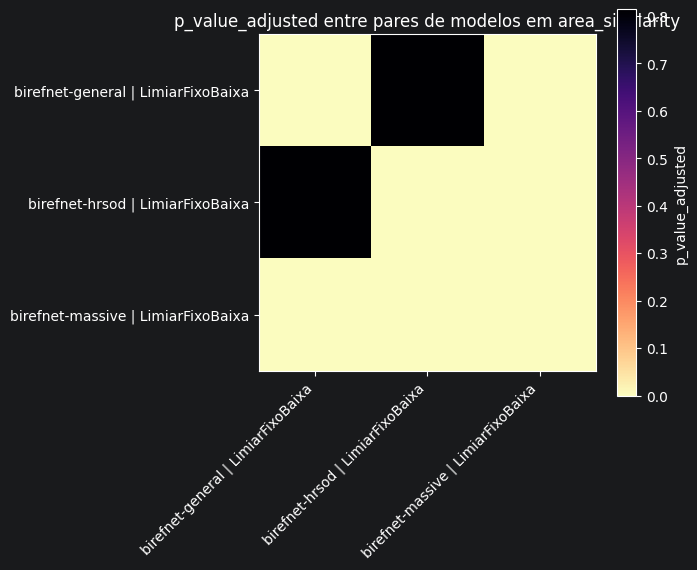

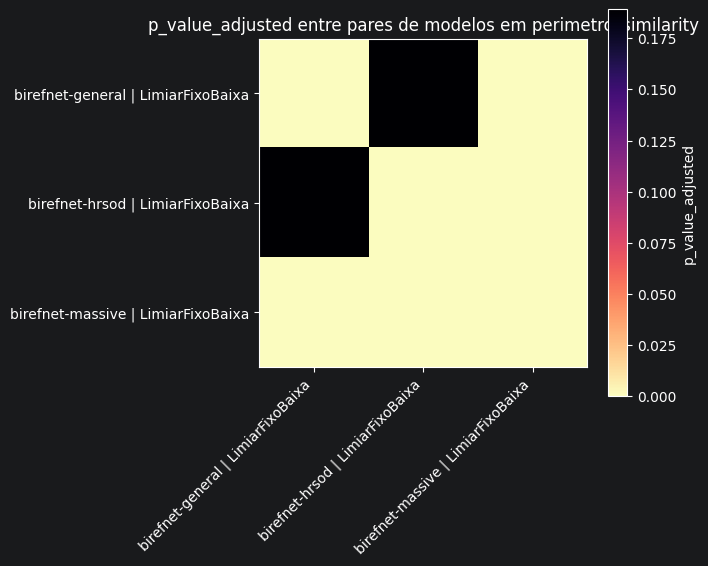

In [6]:
df_base_testes_finalistas = df_finalistas_base.drop(columns=['modelo']).rename(columns={'combo': 'modelo'}).copy()

df_testes_finalistas = build_model_comparison_tests(
    df_base_testes_finalistas,
    metric_configs=BINARIZED_METRIC_CONFIGS,
)
display(df_testes_finalistas)
export_table_csv(
    artifact_output_dir,
    build_artifact_stem('notebook_08_validacao_final_melhores_modelos', 'tabela', 'testes_finalistas'),
    df_testes_finalistas,
)

for metric_name in metric_names:
    df_plot = df_testes_finalistas.loc[
        (df_testes_finalistas['metric_name'] == metric_name)
        & (df_testes_finalistas['comparison_scope'] == 'pairwise')
    ].copy()
    if df_plot.empty:
        continue
    fig, _ = plot_pairwise_pvalue_heatmap(df_testes_finalistas, metric_name)
    export_figure_with_csv(
        artifact_output_dir,
        build_artifact_stem('notebook_08_validacao_final_melhores_modelos', 'heatmap_pvalor', metric_name),
        fig,
        df_plot,
    )
    plt.show()
    plt.close(fig)


## Conclusao da validacao final

A conclusao abaixo resume os modelos selecionados, suas binarizacoes vencedoras e o resultado da regra de aceitacao configurada.

In [7]:
aprovados = df_decisao_thresholds.loc[df_decisao_thresholds['aprovado'], 'combo'].tolist()
reprovados = df_decisao_thresholds.loc[~df_decisao_thresholds['aprovado'], ['combo', 'metricas_reprovadas']].copy()

selected_description = ', '.join(df_decisao_thresholds['combo'].tolist())
if len(aprovados) == len(df_decisao_thresholds):
    status_final = 'As melhores combinacoes disponiveis passaram em todas as metricas configuradas. Com os thresholds atuais, ha evidencia de suficiencia para segmentar bufalos sem retreinamento imediato.'
else:
    detalhes_reprovacao = '; '.join(
        f"{row.combo} falhou em {row.metricas_reprovadas}"
        for row in reprovados.itertuples(index=False)
    )
    status_final = 'Nem mesmo as melhores combinacoes disponiveis passaram no criterio minimo configurado para todas as metricas. Isso indica que o pipeline atual ainda nao e suficiente e fortalece a necessidade de retreinamento ou ajuste especifico para bufalos. ' + detalhes_reprovacao

mensagem = (
    f'Finalistas avaliados no cenario `{VALIDACAO_FINAL_CENARIO_BASE}`: {selected_description}.\n\n'
    f'Regra de aceitacao: `{VALIDACAO_FINAL_ACCEPTANCE_RULE}` com thresholds {metric_thresholds}.\n\n'
    + status_final
)
display(Markdown(mensagem))

Finalistas avaliados no cenario `apenas_ok`: birefnet-general | LimiarFixoBaixa, birefnet-hrsod | LimiarFixoBaixa, birefnet-massive | LimiarFixoBaixa.

Regra de aceitacao: `all_metrics` com thresholds {'iou': 0.97, 'precision': 0.99, 'recall': 0.985, 'area_similarity': 0.99, 'perimetro_similarity': 0.96}.

As melhores combinacoes disponiveis passaram em todas as metricas configuradas. Com os thresholds atuais, ha evidencia de suficiencia para segmentar bufalos sem retreinamento imediato.

## Artefatos exportados

Os graficos e tabelas deste notebook sao exportados em PNG e CSV para consumo posterior por IA, sem gerar PDF.

In [8]:
print(f'Artefatos do notebook 08 salvos em: {artifact_output_dir}')

Artefatos do notebook 08 salvos em: /home/victor/Desktop/projeto-bufalos/worktrees/analise-estatistica-segmentacao-bruta/generated/notebook_08_validacao_final_melhores_modelos
